# Charlotte Walkthrough

This notebook is a guided run-through of `charlotte_5y.py` – it imports the
real functions from that script rather than reimplementing anything, so what
you see here is exactly what `python charlotte_5y.py` produces, just broken
into steps with commentary.

The approach: fit two models (damped-trend ETS and ARIMA(1,1,1)) on
Charlotte's annual population series, backtest both with a rolling 5-year-ahead
window to see which one actually predicted better historically, then use the
backtest winner's confidence interval as the basis for the forward forecast.

See `SOURCES.md` for where the underlying population series comes from and
why the 2009-2010 jump is a metro-boundary change, not real growth.

In [1]:
import matplotlib.pyplot as plt

from charlotte_5y import (
    load_data, fit, rolling_backtest, forecast_horizon,
    plot_backtest, plot_forecast, MODELS, HORIZON,
)

%matplotlib inline

## 1. Load the data

`data/charlotte_population_updated.csv` holds one row per year: the Charlotte metro area's July 1 population estimate. `load_data` reads it into two NumPy arrays (years, population). Display for visibility.

In [2]:
years, series = load_data("data/charlotte_population_updated.csv")
print(f"{years[0]}-{years[-1]}, {len(years)} annual observations")
print(f"Latest ({years[-1]}): {series[-1]:,.0f}")

1950-2025, 76 annual observations
Latest (2025): 2,367,000


## 2. Backtest: which model actually predicts 5 years out better?

`rolling_backtest` refits the model at every historical point and checks its
5-year-ahead prediction against what actually happened – this is the only
fair way to compare models, since a model can look great in-sample and still
be a bad forecaster.

In [3]:
alpha = 0.01  # 99% confidence interval

bt_results = {}
for m in MODELS:
    mae, rmse, preds, lower, upper, start = rolling_backtest(series, m, alpha=alpha)
    bt_results[m] = {"mae": mae, "rmse": rmse, "preds": preds, "lower": lower, "upper": upper, "start": start}
    print(f"{m:>6}:  MAE = {mae:>10,.0f}   RMSE = {rmse:>10,.0f}")

   ets:  MAE =     43,423   RMSE =     47,024
 arima:  MAE =    152,422   RMSE =    166,351


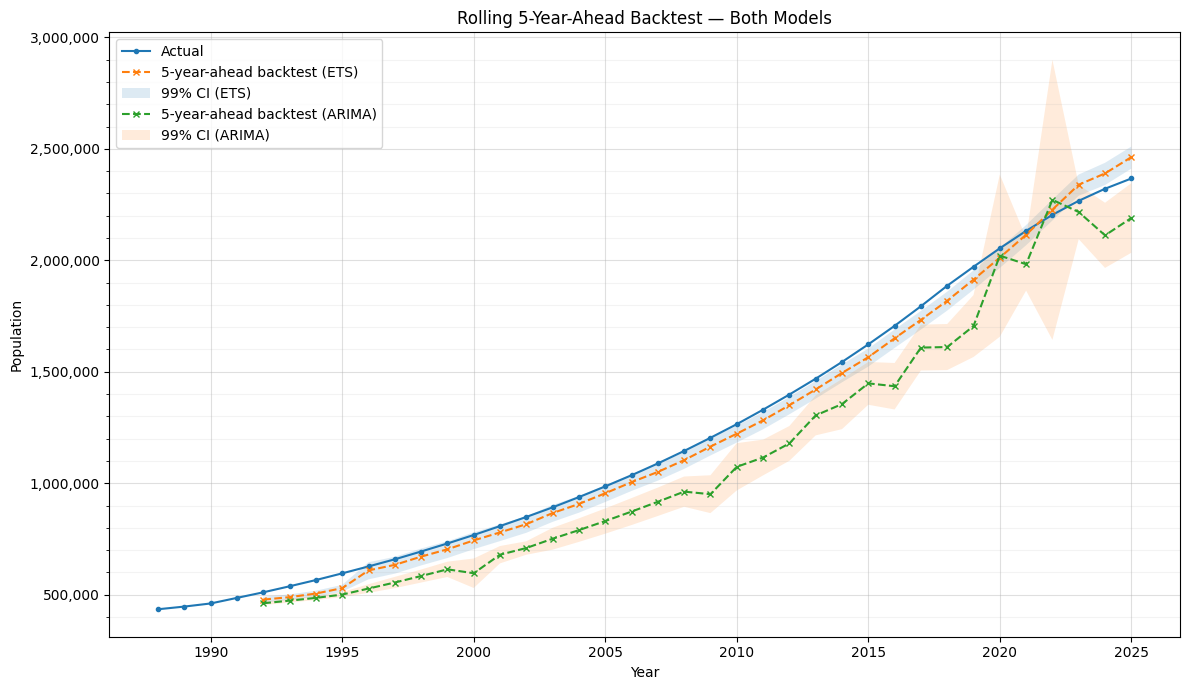

In [10]:
plot_backtest(years, series, bt_results, horizon=HORIZON, alpha=alpha)
plt.show()

## 3. Forward forecast

Whichever model backtested better, both are fit on the full history here so
you can compare their forward-looking forecasts side by side.

ETS: 2030 forecast = 2,593,573  [2,530,401, 2,651,463]
ARIMA: 2030 forecast = 2,487,370  [2,074,849, 2,899,891]


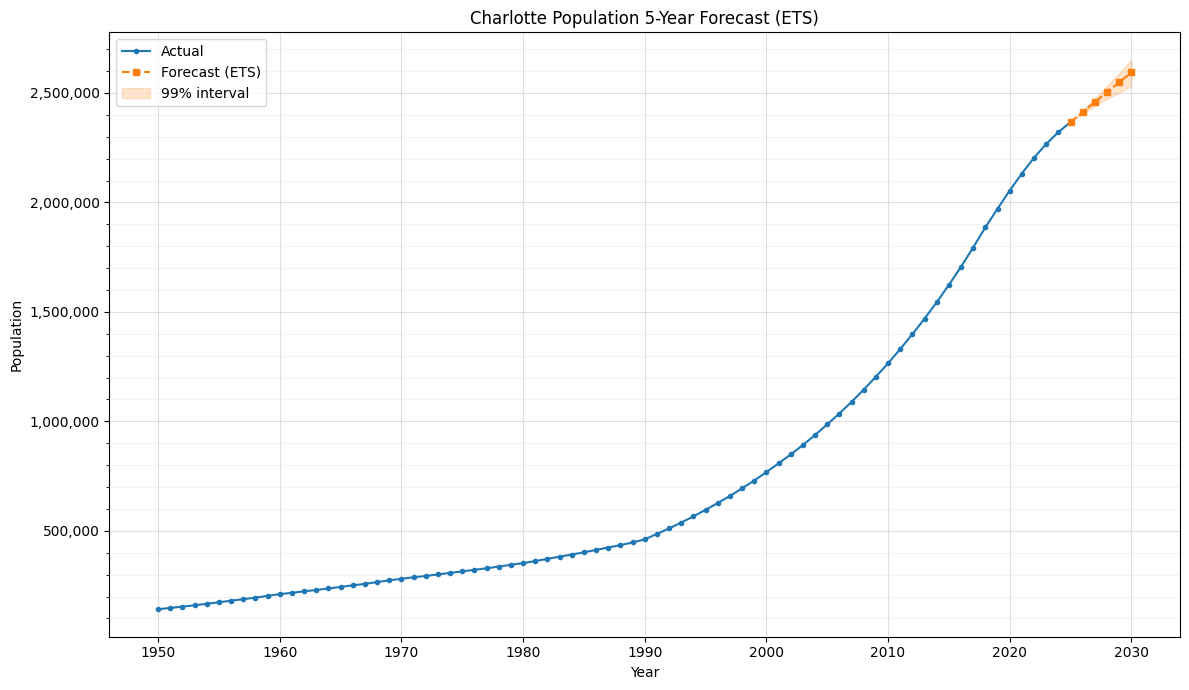

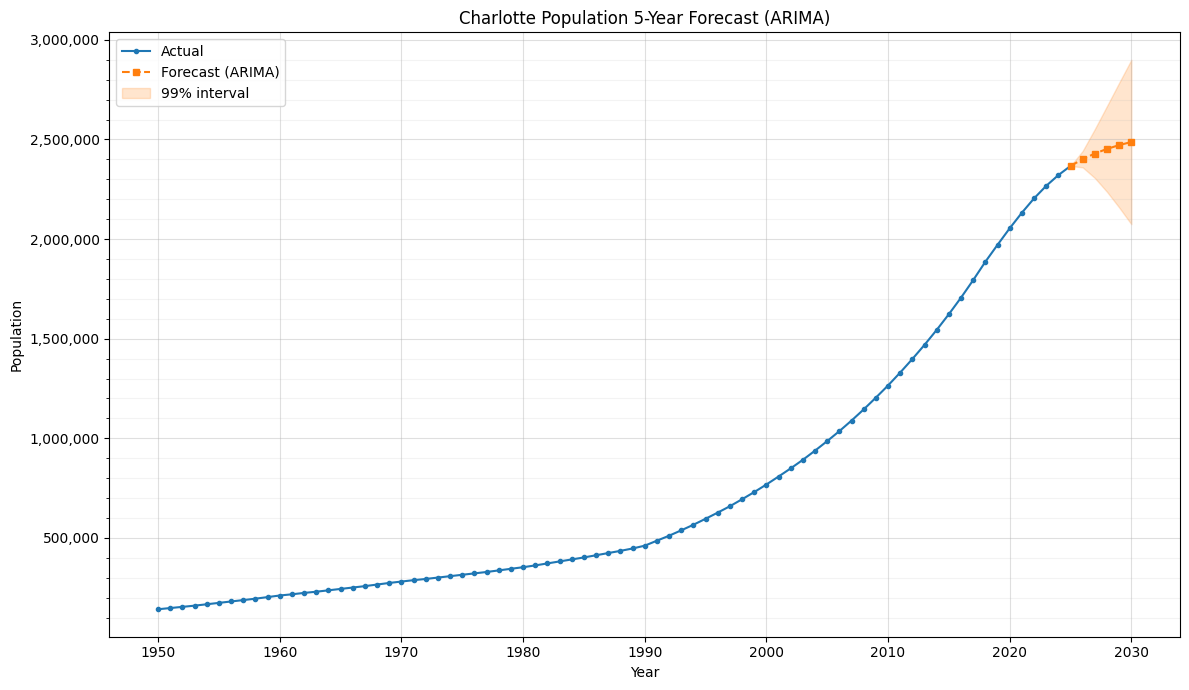

In [4]:
import numpy as np

last_year = int(years[-1])
future_years = np.arange(last_year + 1, last_year + HORIZON + 1)

for m in MODELS:
    fitted = fit(series, m)
    mean, lower, upper = forecast_horizon(fitted, m, alpha=alpha)
    print(f"{m.upper()}: {future_years[-1]} forecast = {mean[-1]:,.0f}  "
          f"[{lower[-1]:,.0f}, {upper[-1]:,.0f}]")
    plot_forecast(years, series, future_years, mean, lower, upper, m, conf=1 - alpha, horizon=HORIZON)

plt.show()

## Adapting this to another city

`fit`, `rolling_backtest`, and `forecast_horizon` are not suited to Charlotte specifically – they use a NumPy array of annual values. To point this at a different place, swap `load_data(...)` for any (years, population) pair of your own, e.g. pulled with `../model_benchmark/core/census.py`'s `build_panel`/`city_series` (pass `variables=[POP_VAR]`). `../florida/population_forecast.py` reuses this same modeling code for several Florida cities at once.

## (In-Progress) Multi-state forecasting